<a href="https://colab.research.google.com/github/PanconquesoHH/Lab-2/blob/main/Copia_de_02_reg_lin_mul_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de programación Regresión Lineal Multiple

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

## 2 Regresión lineal con multiples variables

Se implementa la regresion lineal multivariable para predecir el precio de las casas. El archivo `Datasets/ex1data2.txt` contiene un conjunto de entrenamiento de precios de casas en Portland, Oregon. La primera columna es el tamaño de la casa en metros cuadrados, la segunda columna es el numero de cuartos, y la tercera columna es el precio de la casa.

<a id="section4"></a>
### 2.1 Normalización de caracteristicas

Al visualizar los datos se puede observar que las caracteristicas tienen diferentes magnitudes, por lo cual se debe transformar cada valor en una escala de valores similares, esto con el fin de que el descenso por el gradiente pueda converger mas rapidamente.

In [30]:
# Cargar datos
dataset = '/content/drive/MyDrive/FIFA 22/fifa_players.csv'

print(f'Archivo a usar: {os.path.abspath(dataset)}')

df = pd.read_csv(dataset, sep=',', header=0)

# Eliminar columna de índice si existe
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Variable objetivo
y = df['wage_eur'].values

# Variables predictoras
X_df = df.drop(columns=['wage_eur']).copy()

print(f'Número de muestras: {len(y)}')
print(f'Número de características: {X_df.shape[1]}')

print(f'Tamaño de X: {X_df.shape}')
print(f'Tamaño de y: {y.shape}')

print(f'Tamaño del dataset: {df.shape}')

Archivo a usar: /content/drive/MyDrive/FIFA 22/fifa_players.csv
Número de muestras: 19178
Número de características: 28
Tamaño de X: (19178, 28)
Tamaño de y: (19178,)
Tamaño del dataset: (19178, 29)


### Explicación de los cambios en la carga y preprocesamiento de datos

Se ha modificado la celda de carga de datos (`6BP5grkxlHQ0`) para corregir varios problemas:

1.  **Carga con encabezado**: El archivo CSV ahora se carga con `header=0`, lo que instruye a `pandas` a usar la primera fila como nombres de columna, en lugar de tratarla como datos.
2.  **Separación de `X` y `y`**: Se ha separado `y` (la columna 'wage_eur', que es la variable objetivo que queremos predecir) del resto de las columnas, que forman la matriz de características `X`.
3.  **Manejo de valores nulos**: Antes de la codificación, se manejan los valores nulos (`NaN`):
    *   Para las columnas numéricas, los `NaN` se rellenan con la media de la columna.
    *   Para las columnas categóricas (texto), los `NaN` se rellenan con la cadena `'Missing_Category'`.
4.  **Conversión de texto a números (Label Encoding)**: Las columnas que contienen datos de tipo `object` (generalmente cadenas de texto) se han convertido a valores numéricos enteros utilizando `LabelEncoder` de `sklearn.preprocessing`. Esto asigna un número único a cada categoría de texto. Se ha almacenado un diccionario (`label_encoders`) para cada codificador, lo que permite ver el mapeo de cadena a número.
5.  **Conversión final a NumPy**: Finalmente, tanto `X` como `y` se han convertido a arrays de `numpy` con tipos de datos numéricos adecuados (`float` o `int`), lo que permitirá que la función `featureNormalize` funcione correctamente sin errores de tipo.

In [32]:
from sklearn.preprocessing import LabelEncoder

# Diccionario para guardar los codificadores
label_encoders = {}

# Convertir columnas categóricas a números
for col in X_df.columns:

    if X_df[col].dtype == 'object':

        le = LabelEncoder()

        # Convertir valores NaN a string antes de codificar
        X_df[col] = X_df[col].fillna('Missing').astype(str)

        # Transformar texto a números
        X_df[col] = le.fit_transform(X_df[col])

        # Guardar el encoder
        label_encoders[col] = le

    else:
        # Convertir columnas numéricas
        X_df[col] = pd.to_numeric(X_df[col], errors='coerce')

        # Rellenar valores faltantes con la media
        X_df[col] = X_df[col].fillna(X_df[col].mean())

# Convertir X a NumPy
X = X_df.values.astype(float)

# Convertir y a numérico
y = pd.to_numeric(y, errors='coerce')

# Rellenar valores faltantes de y
y = np.nan_to_num(y, nan=np.nanmean(y))

# Actualizar dimensiones
m = X.shape[0]
n = X.shape[1]

print(f'Número de muestras: {m}')
print(f'Número de características: {n}')
print(f'Tamaño de X: {X.shape}')
print(f'Tamaño de y: {y.shape}')

# Diccionarios de mapeo de string a números
print('Diccionarios de LabelEncoder para columnas categóricas:')

for col, encoder in label_encoders.items():

    print(f'\nColumna: {col}')

    mapping = {
        label: index
        for index, label in enumerate(encoder.classes_)
    }

    display(mapping)

print('\nPrimeras filas de X después del preprocesamiento:')
display(X[:5])

print('\nPrimeras filas de y:')
display(y[:5])

print('\nTipo de datos de X:')
print(X.dtype)

print('\nValores NaN en X:')
print(np.isnan(X).sum())

print('\nValores NaN en y:')
print(np.isnan(y).sum())

Número de muestras: 19178
Número de características: 28
Tamaño de X: (19178, 28)
Tamaño de y: (19178,)
Diccionarios de LabelEncoder para columnas categóricas:

Primeras filas de X después del preprocesamiento:


array([[ 34., 170.,  72.,   6.,  93.,  93.,  85.,  95.,  70.,  91.,  88.,
         96.,  93.,  94.,  91.,  96.,  91.,  80.,  91.,  94.,  95.,  35.,
         24.,   6.,  11.,  15.,  14.,   8.],
       [ 32., 185.,  81., 123.,  92.,  92.,  71.,  95.,  90.,  85.,  89.,
         85.,  79.,  85.,  70.,  88.,  77.,  79.,  77.,  93.,  82.,  42.,
         19.,  15.,   6.,  12.,   8.,  10.],
       [ 36., 187.,  83., 124.,  91.,  91.,  87.,  95.,  90.,  80.,  86.,
         88.,  81.,  84.,  77.,  88.,  85.,  88.,  86.,  94.,  74.,  32.,
         24.,   7.,  11.,  15.,  14.,  11.],
       [ 29., 175.,  68.,  20.,  91.,  91.,  85.,  83.,  63.,  86.,  86.,
         95.,  88.,  87.,  81.,  95.,  93.,  89.,  96.,  89.,  84.,  32.,
         29.,   9.,   9.,  15.,  15.,  11.],
       [ 30., 181.,  70.,  13.,  91.,  91.,  94.,  82.,  55.,  94.,  82.,
         88.,  85.,  83.,  93.,  91.,  76.,  76.,  79.,  91.,  78.,  65.,
         53.,  15.,  13.,   5.,  10.,  13.]])


Primeras filas de y:


array([320000., 270000., 270000., 270000., 350000.])


Tipo de datos de X:
float64

Valores NaN en X:
0

Valores NaN en y:
0


La desviación estándar es una forma de medir cuánta variación hay en el rango de valores de una característica en particular (la mayoría de los puntos caeran en un rango de ± 2 en relación a la desviaciones estándar de la media); esta es una alternativa a tomar el rango de valores (max-min). En `numpy`, se puede usar la función `std` para calcular la desviacion estandar.

Por ejemplo, la caracteristica`X[:, 0]` contiene todos los valores de $x_1$ (tamaño de las casas) en el conjunto de entrenamiento, entonces `np.std(X[:, 0])` calcula la desviacion estandar de los tamaños de las casas.
En el momento en que se llama a la función `featureNormalize`, la columna adicional de unos correspondiente a $ x_0 = 1 $ aún no se ha agregado a $ X $.

<div class="alert alert-block alert-warning">
**Notas para la implementación:** Cuando se normalize una caracteristica, es importante almacenar los valores usados para la normalización - el valor de la media y el valor de la desviación estandar usado para los calculos. Despues de aprender los parametros del modelo, se deseara predecir los precios de casas que no se han visto antes. Dado un nuevo valor de x (area del living room y el numero de dormitorios), primero se debe normalizar x usando la media y la desviacion estandar que se empleo anteriormente en el conjunto de entrenamiento para entrenar el modelo.
</div>
<a id="featureNormalize"></a>

In [40]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Evitar división por cero
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [41]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[ 1.          1.85392389 -1.64502918 ... -0.06336788 -0.13031923
  -0.47472774]
 [ 1.          1.43252162  0.54093165 ... -0.24458004 -0.48227014
  -0.36282597]
 [ 1.          2.27532615  0.83239309 ... -0.06336788 -0.13031923
  -0.30687508]
 ...
 [ 1.         -0.88519087 -0.4791834  ... -0.54660032 -0.36495317
  -0.58662952]
 [ 1.         -1.30659313 -1.20783701 ... -0.54660032 -0.13031923
  -0.08307152]
 [ 1.         -1.30659313 -2.08222134 ... -0.18417599 -0.42361165
  -0.13902241]]
Media calculada: [ 1.00000000e+00 -2.84543133e-16 -6.86163910e-16  8.35845454e-16
  1.17077643e-16  1.89695422e-16  5.92798194e-16  2.37119278e-17
 -1.30415603e-16 -1.30415603e-16 -1.89695422e-16 -1.65983494e-16
 -1.42271567e-16  1.65983494e-16 -1.30415603e-16  2.37119278e-17
  1.89695422e-16 -3.43822953e-16  3.91246808e-16  4.74238556e-17
  2.37119278e-17  2.72687169e-16  1.18559639e-16  1.65983494e-16
 -1.03739684e-16  1.48199549e-17 -4.74238556e-17  2.51939233e-17
 -5.92798194e-17]
Desviación estanda

Despues de `featureNormalize` la funcion es provada, se añade el temino de interseccion a `X_norm`:

In [35]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [36]:
print(X[:,3])

[-0.41476745  0.85904781  1.14211787 ... -0.41476745 -1.26397763
 -1.97165277]


<a id="section5"></a>
### 2.2 Descenso por el gradiente

En el ejemplo anterior se implemento el descenso por el gradiente para un problema de regresion univariable. La unica diferencia es que ahora existe una caracteristica adicional en la matriz $X$. La función de hipótesis y la regla de actualización del descenso del gradiente por lotes permanecen sin cambios.

La implementacion de las funciones `computeCostMulti` y `gradientDescentMulti` son similares a la funcion de costo y función de descenso por el gradiente de la regresión lineal multiple es similar al de la regresion lineal multivariable. Es importante garantizar que el codigo soporte cualquier numero de caracteristicas y esten bien vectorizadas.

Se puede utilizar `shape`, propiedad de los arrays `numpy`, para identificar cuantas caracteristicas estan consideradas en el dataset.

<div class="alert alert-block alert-warning">
**Nota de implementación:** En el caso de multivariables, la función de costo puede se escrita considerando la forma vectorizada de la siguiente manera:

$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$

donde:

$$ X = \begin{pmatrix}
- (x^{(1)})^T - \\
- (x^{(2)})^T - \\
\vdots \\
- (x^{(m)})^T - \\ \\
\end{pmatrix} \qquad \mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \\\end{bmatrix}$$

La version vectorizada es eficiente cuando se trabaja con herramientas de calculo numericos computacional como `numpy`.
</div>

<a id="computeCostMulti"></a>

In [37]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [42]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    m = y.shape[0]

    theta = theta.copy()
    J_history = []

    for i in range(num_iters):

        error = np.dot(X, theta) - y

        gradient = (1 / m) * np.dot(X.T, error)

        theta = theta - alpha * gradient

        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 3.2.1 Seleccionando coheficientes de aprendizaje


theta calculado por el descenso por el gradiente: [ 9017.98936281 -1377.15419858  1152.46731391  -215.66736652
  -128.39554144  9823.67696628  2693.57605862   611.15062168
  -547.8032786   -483.52921426  -904.62239481  1613.04168091
  -333.85505153   884.75070348  -195.91655594   772.47680618
 -2303.00175498 -1120.71464903   321.95039514  -986.66668861
  1820.21961819  1760.92315961   253.03483871  -968.62758104
  -272.68922892  -129.64997258   707.13039804 -1894.19026821
  -425.93506372]
El salario predecido para el primer jugador del dataset (usando el descenso por el gradiente): $60979


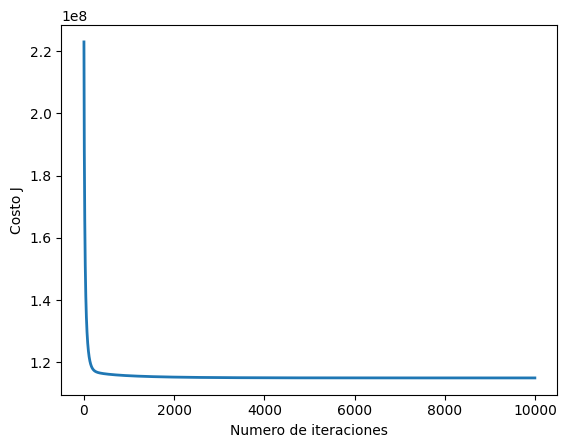

In [49]:
alpha = 0.01 # Reducir alpha para evitar divergencia, por ejemplo, 1e-7
num_iters = 10000 # Incrementar el numero de iteraciones para permitir la convergencia con un alpha pequeño

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# Estimar el salario para un jugador
# X_array ya esta normalizado y con el termino de intercepto, por lo que no necesita re-normalizarse.
X_array = X[0, :] # Usamos la primera fila de X (ya preprocesada y normalizada) como ejemplo
# Eliminamos la línea de re-normalización, ya que X ya está normalizado
price = np.dot(X_array, theta)

print('El salario predecido para el primer jugador del dataset (usando el descenso por el gradiente): ${:.0f}'.format(price))

In [14]:
X_array = [1, 1222, 3]
# X_array[1:3] = (X_array[1:3] - mu) / sigma

In [15]:
X_array = X[0, :] # Usamos la primera fila de X (ya con el intercepto) como ejemplo para la predicción
price = np.dot(X_array, theta)

print('El salario predecido para el primer jugador del dataset (usando la ecuación de la normal): ${:.0f}'.format(price))

El salario predecido para el primer jugador del dataset (usando la ecuación de la normal): $266


<a id="section7"></a>
### 2.3 Ecuacion de la Normal

Una manera de calcular rapidamente el modelo de una regresion lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Utilizando esta formula no requiere que se escale ninguna caracteristica, y se obtendra una solucion exacta con un solo calculo: no hay “bucles de convergencia” como en el descenso por el gradiente.

Primero se recargan los datos para garantizar que las variables no esten modificadas. Recordar que no es necesario escalar las caracteristicas, se debe agregar la columna de unos a la matriz $X$ para tener el termino de intersección($\theta_0$).

In [18]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Recargar los datos para la Ecuación Normal, forzando la lectura de todas las columnas como string
dataset = '/content/drive/MyDrive/FIFA 22/fifa_players.csv'
print(f'Archivo a usar: {os.path.abspath(dataset)}')
df_normal_eqn = pd.read_csv(dataset, sep=',', header=0, dtype=str) # Leer con encabezado y como string

# Eliminar columna 'Unnamed: 0' si existe
if 'Unnamed: 0' in df_normal_eqn.columns:
    df_normal_eqn = df_normal_eqn.drop(columns=['Unnamed: 0'])

# Separar la variable objetivo (y) de las características (X_df)
if 'wage_eur' in df_normal_eqn.columns:
    y_normal_eqn = pd.to_numeric(df_normal_eqn['wage_eur'], errors='coerce')
    X_df_normal_eqn = df_normal_eqn.drop(columns=['wage_eur']).copy()
else:
    print("Advertencia: columna 'wage_eur' no encontrada. Verifique el nombre de la variable objetivo.")
    y_normal_eqn = pd.to_numeric(df_normal_eqn.iloc[:, 0], errors='coerce')
    X_df_normal_eqn = df_normal_eqn.iloc[:, 1:].copy()

# Rellenar NaNs en y_normal_eqn
y_normal_eqn = y_normal_eqn.fillna(y_normal_eqn.mean() if not y_normal_eqn.isnull().all() else 0).astype(float)

normal_eqn_label_encoders = {}
categorical_cols_normal_eqn = []

for col in X_df_normal_eqn.columns:
    # Manejar representaciones de string de byte (e.g., 'b\'Argentina\'')
    if X_df_normal_eqn[col].apply(lambda x: isinstance(x, str) and x.startswith("b'") and x.endswith("'")).any():
        X_df_normal_eqn[col] = X_df_normal_eqn[col].apply(lambda x: x[2:-1] if isinstance(x, str) and x.startswith("b'") and x.endswith("'") else x)

    # Intentar convertir la columna a numérica
    numeric_candidate_normal_eqn = pd.to_numeric(X_df_normal_eqn[col], errors='coerce')

    # Determinar si es categórica por la presencia de strings no numéricos
    non_numeric_elements_count_normal_eqn = X_df_normal_eqn[col].notna().sum() - numeric_candidate_normal_eqn.notna().sum()

    if non_numeric_elements_count_normal_eqn > 0: # Indica que había strings no numéricos
        categorical_cols_normal_eqn.append(col)
        # Rellenar NaNs para columnas categóricas con un marcador de posición
        X_df_normal_eqn[col] = X_df_normal_eqn[col].fillna('Missing_Category')
        le = LabelEncoder()
        X_df_normal_eqn[col] = le.fit_transform(X_df_normal_eqn[col])
        normal_eqn_label_encoders[col] = le # Almacenar el codificador
    else:
        # Es una columna numérica. Usar la columna numérica convertida.
        X_df_normal_eqn[col] = numeric_candidate_normal_eqn
        # Rellenar NaNs con la media de la columna
        X_df_normal_eqn[col] = X_df_normal_eqn[col].fillna(X_df_normal_eqn[col].mean() if not X_df_normal_eqn[col].isnull().all() else 0)

# Convertir el DataFrame procesado a un array NumPy
X_normal_eqn = X_df_normal_eqn.values.astype(float)
y_normal_eqn = y_normal_eqn.values.astype(float) # Actualizar 'y' global para la ecuación normal

# Añadir el término de intercepción (columna de unos) a X para la Ecuación Normal
m_normal_eqn = y_normal_eqn.size
X_normal_eqn = np.concatenate([np.ones((m_normal_eqn, 1)), X_normal_eqn], axis=1)

# Diccionarios de mapeo de string a números para las columnas categóricas en la Ecuación Normal
print('Diccionarios de LabelEncoder para columnas categóricas en la Ecuación Normal:')
for col, encoder in normal_eqn_label_encoders.items():
    print(f'Columna: {col}')
    # Display the mapping by creating a dictionary from classes_ and their enumerated indices
    mapping = {label: index for index, label in enumerate(encoder.classes_)}
    display(mapping)

print('\nPrimeras filas de X (después del preprocesamiento para la Ecuación Normal):')
display(X_normal_eqn[:5])
print('\nPrimeras filas de y (después del preprocesamiento para la Ecuación Normal):')
display(y_normal_eqn[:5])

print(f'Número de muestras: {m_normal_eqn}')
print(f'Número de características: {X_normal_eqn.shape[1]}')
print(f'Tamaño de X: {X_normal_eqn.shape}')
print(f'Tamaño de y: {y_normal_eqn.shape}')
print(f'Tamaño del dataset original: {df_normal_eqn.shape}')

print(f'Columnas categóricas procesadas para la Ecuación Normal: {categorical_cols_normal_eqn}')

Archivo a usar: /content/drive/MyDrive/FIFA 22/fifa_players.csv
Diccionarios de LabelEncoder para columnas categóricas en la Ecuación Normal:
Columna: nationality_name


{'Afghanistan': 0,
 'Albania': 1,
 'Algeria': 2,
 'Andorra': 3,
 'Angola': 4,
 'Antigua and Barbuda': 5,
 'Argentina': 6,
 'Armenia': 7,
 'Australia': 8,
 'Austria': 9,
 'Azerbaijan': 10,
 'Barbados': 11,
 'Belarus': 12,
 'Belgium': 13,
 'Belize': 14,
 'Benin': 15,
 'Bermuda': 16,
 'Bhutan': 17,
 'Bolivia': 18,
 'Bosnia and Herzegovina': 19,
 'Brazil': 20,
 'Bulgaria': 21,
 'Burkina Faso': 22,
 'Burundi': 23,
 'Cameroon': 24,
 'Canada': 25,
 'Cape Verde Islands': 26,
 'Central African Republic': 27,
 'Chad': 28,
 'Chile': 29,
 'China PR': 30,
 'Chinese Taipei': 31,
 'Colombia': 32,
 'Comoros': 33,
 'Congo': 34,
 'Congo DR': 35,
 'Costa Rica': 36,
 'Croatia': 37,
 'Cuba': 38,
 'Curacao': 39,
 'Cyprus': 40,
 'Czech Republic': 41,
 'Denmark': 42,
 'Dominican Republic': 43,
 'Ecuador': 44,
 'Egypt': 45,
 'El Salvador': 46,
 'England': 47,
 'Equatorial Guinea': 48,
 'Eritrea': 49,
 'Estonia': 50,
 'Ethiopia': 51,
 'Faroe Islands': 52,
 'Fiji': 53,
 'Finland': 54,
 'France': 55,
 'Gabon': 56


Primeras filas de X (después del preprocesamiento para la Ecuación Normal):


array([[  1.,  34., 170.,  72.,   6.,  93.,  93.,  85.,  95.,  70.,  91.,
         88.,  96.,  93.,  94.,  91.,  96.,  91.,  80.,  91.,  94.,  95.,
         35.,  24.,   6.,  11.,  15.,  14.,   8.],
       [  1.,  32., 185.,  81., 123.,  92.,  92.,  71.,  95.,  90.,  85.,
         89.,  85.,  79.,  85.,  70.,  88.,  77.,  79.,  77.,  93.,  82.,
         42.,  19.,  15.,   6.,  12.,   8.,  10.],
       [  1.,  36., 187.,  83., 124.,  91.,  91.,  87.,  95.,  90.,  80.,
         86.,  88.,  81.,  84.,  77.,  88.,  85.,  88.,  86.,  94.,  74.,
         32.,  24.,   7.,  11.,  15.,  14.,  11.],
       [  1.,  29., 175.,  68.,  20.,  91.,  91.,  85.,  83.,  63.,  86.,
         86.,  95.,  88.,  87.,  81.,  95.,  93.,  89.,  96.,  89.,  84.,
         32.,  29.,   9.,   9.,  15.,  15.,  11.],
       [  1.,  30., 181.,  70.,  13.,  91.,  91.,  94.,  82.,  55.,  94.,
         82.,  88.,  85.,  83.,  93.,  91.,  76.,  76.,  79.,  91.,  78.,
         65.,  53.,  15.,  13.,   5.,  10.,  13.]])


Primeras filas de y (después del preprocesamiento para la Ecuación Normal):


array([320000., 270000., 270000., 270000., 350000.])

Número de muestras: 19178
Número de características: 29
Tamaño de X: (19178, 29)
Tamaño de y: (19178,)
Tamaño del dataset original: (19178, 29)
Columnas categóricas procesadas para la Ecuación Normal: ['nationality_name']


In [19]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [20]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Recargar los datos para la Ecuación Normal, forzando la lectura de todas las columnas como string
dataset = '/content/drive/MyDrive/FIFA 22/fifa_players.csv'
print(f'Archivo a usar: {os.path.abspath(dataset)}')
df_normal_eqn = pd.read_csv(dataset, sep=',', header=0, dtype=str) # Leer con encabezado y como string

# Eliminar columna 'Unnamed: 0' si existe
if 'Unnamed: 0' in df_normal_eqn.columns:
    df_normal_eqn = df_normal_eqn.drop(columns=['Unnamed: 0'])

# Separar la variable objetivo (y) de las características (X_df)
if 'wage_eur' in df_normal_eqn.columns:
    y_normal_eqn = pd.to_numeric(df_normal_eqn['wage_eur'], errors='coerce')
    X_df_normal_eqn = df_normal_eqn.drop(columns=['wage_eur']).copy()
else:
    print("Advertencia: columna 'wage_eur' no encontrada. Verifique el nombre de la variable objetivo.")
    y_normal_eqn = pd.to_numeric(df_normal_eqn.iloc[:, 0], errors='coerce')
    X_df_normal_eqn = df_normal_eqn.iloc[:, 1:].copy()

# Rellenar NaNs en y_normal_eqn
y_normal_eqn = y_normal_eqn.fillna(y_normal_eqn.mean() if not y_normal_eqn.isnull().all() else 0).astype(float)

normal_eqn_label_encoders = {}
categorical_cols_normal_eqn = []

for col in X_df_normal_eqn.columns:
    # Manejar representaciones de string de byte (e.g., 'b\'Argentina\'')
    if X_df_normal_eqn[col].apply(lambda x: isinstance(x, str) and x.startswith("b'") and x.endswith("'")).any():
        X_df_normal_eqn[col] = X_df_normal_eqn[col].apply(lambda x: x[2:-1] if isinstance(x, str) and x.startswith("b'") and x.endswith("'") else x)

    # Intentar convertir la columna a numérica
    numeric_candidate_normal_eqn = pd.to_numeric(X_df_normal_eqn[col], errors='coerce')

    # Determinar si es categórica por la presencia de strings no numéricos
    non_numeric_elements_count_normal_eqn = X_df_normal_eqn[col].notna().sum() - numeric_candidate_normal_eqn.notna().sum()

    if non_numeric_elements_count_normal_eqn > 0: # Indica que había strings no numéricos
        categorical_cols_normal_eqn.append(col)
        # Rellenar NaNs para columnas categóricas con un marcador de posición
        X_df_normal_eqn[col] = X_df_normal_eqn[col].fillna('Missing_Category')
        le = LabelEncoder()
        X_df_normal_eqn[col] = le.fit_transform(X_df_normal_eqn[col])
        normal_eqn_label_encoders[col] = le # Almacenar el codificador
    else:
        # Es una columna numérica. Usar la columna numérica convertida.
        X_df_normal_eqn[col] = numeric_candidate_normal_eqn
        # Rellenar NaNs con la media de la columna
        X_df_normal_eqn[col] = X_df_normal_eqn[col].fillna(X_df_normal_eqn[col].mean() if not X_df_normal_eqn[col].isnull().all() else 0)

# Convertir el DataFrame procesado a un array NumPy
X = X_df_normal_eqn.values.astype(float)
y = y_normal_eqn.values.astype(float) # Actualizar 'y' global para la ecuación normal

# Añadir el término de intercepción (columna de unos) a X para la Ecuación Normal
m_normal_eqn = y.size
X = np.concatenate([np.ones((m_normal_eqn, 1)), X], axis=1)

m = y.size # Actualizar 'm' global
n = X.shape[1] # Actualizar 'n' global (número de características + 1 por el intercepto)

print(f'Número de muestras: {m}')
print(f'Número de características: {n}')
print(f'Tamaño de X: {X.shape}')
print(f'Tamaño de y: {y.shape}')
print(f'Tamaño del dataset original: {df_normal_eqn.shape}')

print(f'Columnas categóricas procesadas para la Ecuación Normal: {categorical_cols_normal_eqn}')

Archivo a usar: /content/drive/MyDrive/FIFA 22/fifa_players.csv
Número de muestras: 19178
Número de características: 29
Tamaño de X: (19178, 29)
Tamaño de y: (19178,)
Tamaño del dataset original: (19178, 29)
Columnas categóricas procesadas para la Ecuación Normal: ['nationality_name']


In [21]:
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));


# y el 1 para el término de intercepción.

X_array_pred = np.ones(theta.shape[0]) # Crea un array de unos del tamaño de theta (29)



X_array_pred = X[0, :] # Usamos la primera fila de X (ya con el intercepto) como ejemplo

price = np.dot(X_array_pred, theta)

print('Precio predecido (usando la ecuación de la normal): ${:.0f}'.format(price))

Theta calculado a partir de la ecuación de la normal: [-1.40653543e+05 -2.93602354e+02  1.68143879e+02 -3.09081382e+01
 -2.63502312e+00  1.43597195e+03  4.38725172e+02  3.33974272e+01
 -2.80992388e+01 -2.82854098e+01 -6.20057624e+01  9.14815913e+01
 -1.49071606e+01  4.85945260e+01 -1.14030901e+01  5.15728607e+01
 -1.43481057e+02 -7.43475553e+01  2.13684825e+01 -6.64337507e+01
  1.99905863e+02  1.23222605e+02  1.53928642e+01 -5.04559279e+01
 -1.57403827e+01 -7.20906087e+00  4.58103324e+01 -1.15485413e+02
 -2.50555629e+01]
Precio predecido (usando la ecuación de la normal): $61006
